In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import math

In [5]:

file_signal = "/data/mhance/SUSY/ntuples/v3.1/output_Znunu_CVetoBVeto_mc20.root"


with uproot.open(file_signal) as f:
    tree = f["picontuple"]
    data = tree.arrays(library="np")

print(data.keys())

real_mask = data["ph_truthprompt"] == 1

fake_mask = data["ph_truthJFP"] == 1

def plot_one(varname, title, color_real, color_fake, xmax=0.5, bins=100):
    real = data[varname][real_mask] / data["ph_pt"][real_mask]
    fake = data[varname][fake_mask] / data["ph_pt"][fake_mask]

    plt.figure(figsize=(8, 5))
    plt.hist(real, bins=bins, range=(-0.2, xmax), density=True, histtype='step', label="Real photons", color=color_real)
    plt.hist(fake, bins=bins, range=(-0.2, xmax), density=True, histtype='step', label="Fake photons", color=color_fake)
    plt.yscale("log")
    plt.xlabel(f"{varname} / ph_pt")
    plt.ylabel("Normalized Count (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

dict_keys(['ph_pt', 'ph_eta', 'ph_eT2', 'ph_etaS2', 'ph_phi', 'ph_select_baseline', 'ph_select_tightID', 'ph_select_mediumID', 'ph_isEM', 'ph_select_tightIso', 'ph_select_tightCOIso', 'ph_select_looseIso', 'ph_select_hybridIso', 'ph_select_hybridCOIso', 'ph_ptcone20', 'ph_topoetcone20', 'ph_topoetcone40', 'ph_author', 'ph_conversionType', 'ph_truthType', 'ph_truthOrigin', 'ph_truthpt', 'ph_trutheta', 'ph_truthphi', 'ph_truthpdgId', 'ph_id_effSF_baseline', 'ph_id_effSF_tightID', 'ph_id_effSF_mediumID', 'ph_id_effSF_tightIso', 'ph_id_effSF_tightCOIso', 'ph_id_effSF_looseIso', 'ph_id_effSF_hybridIso', 'ph_id_effSF_hybridCOIso', 'ph_truthprompt', 'ph_truthEFP', 'ph_truthJFP', 'ph_truthother', 'met_met', 'met_phi', 'weight_mc', 'weight_pileup', 'weight_total', 'weight_fjvt_effSF', 'weight_ftag_effSF_GN2v01_Continuous', 'weight_jvt_effSF', 'runNumber', 'eventNumber', 'j1_pt', 'j1_eta', 'j1_phi', 'j2_pt', 'j2_eta', 'j2_phi', 'jet_cleanTightBad_prod', 'nJets', 'HTJets', 'nBTagJets', 'met_signi

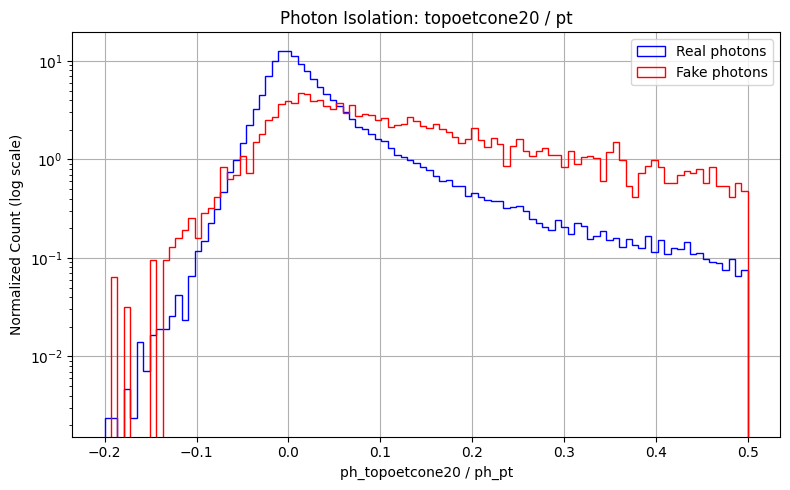

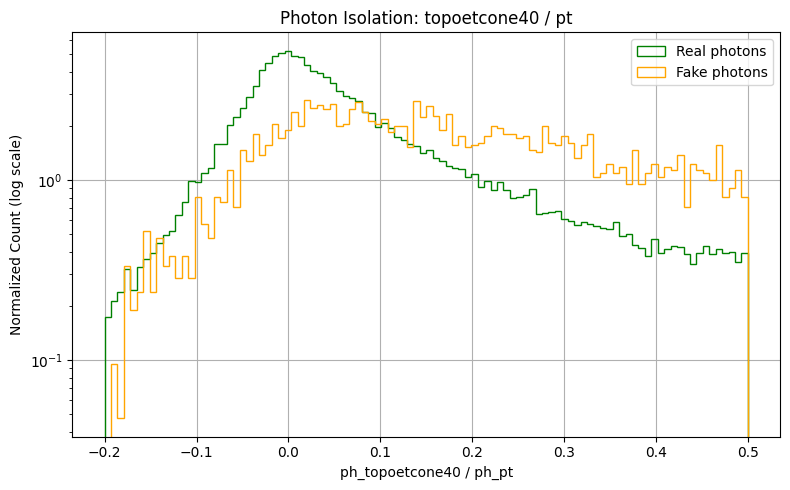

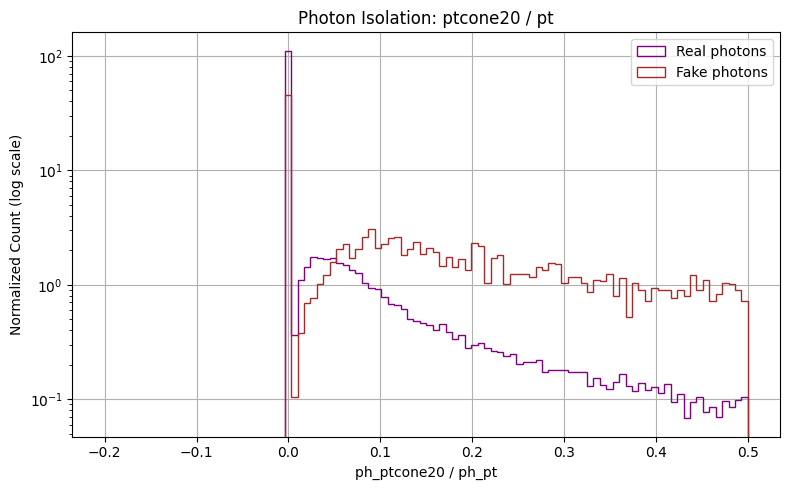

In [28]:

plot_one("ph_topoetcone20", "Photon Isolation: topoetcone20 / pt", "blue", "red")
plot_one("ph_topoetcone40", "Photon Isolation: topoetcone40 / pt", "green", "orange")
plot_one("ph_ptcone20", "Photon Isolation: ptcone20 / pt", "purple", "brown")

In [24]:
pt = data["ph_pt"]
iso1 = data["ph_topoetcone20"]
iso2 = data["ph_ptcone20"]

fixedcutloose_mask = (iso1 < 0.065 * pt) & (iso2 / pt < 0.05)

real_passes = real_mask & fixedcutloose_mask
fake_passes = fake_mask & fixedcutloose_mask

print("Real passing:", np.sum(real_passes))
print("Fake passing:", np.sum(fake_passes))

Real passing: 42898
Fake passing: 49769


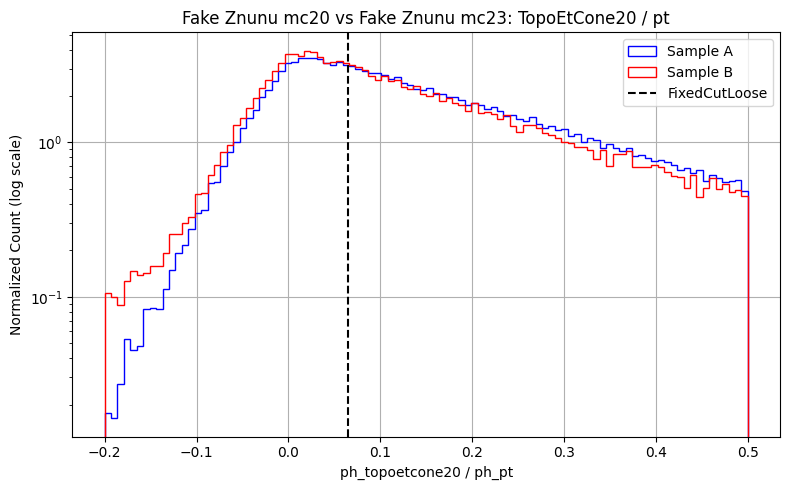

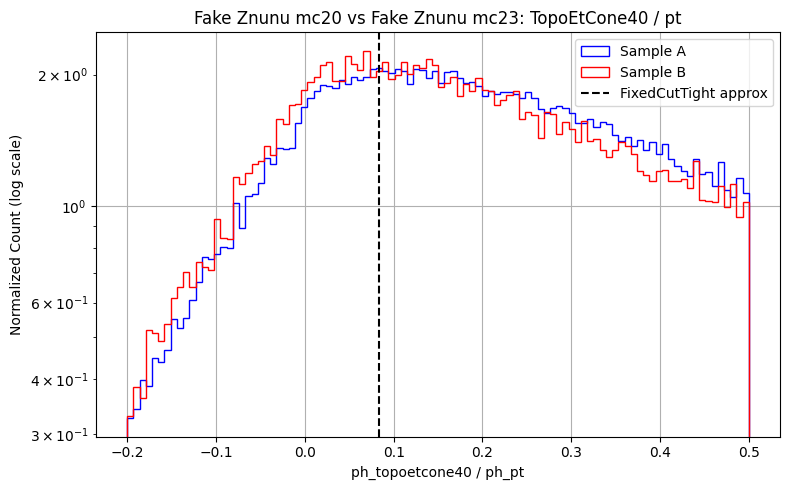

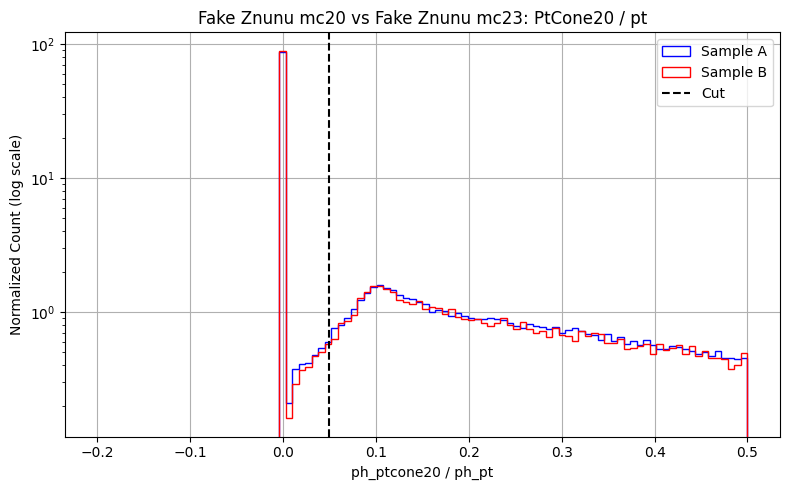

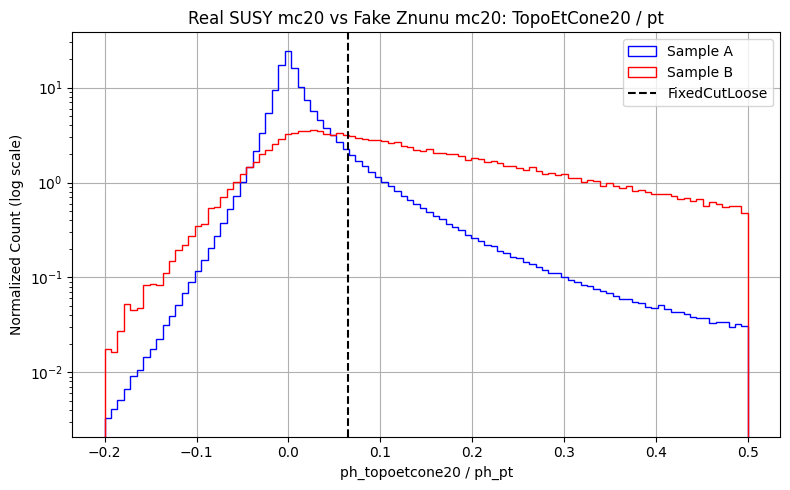

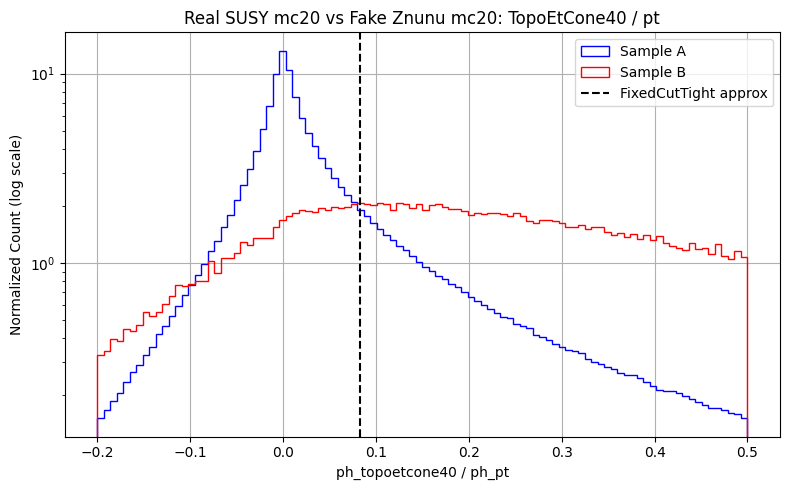

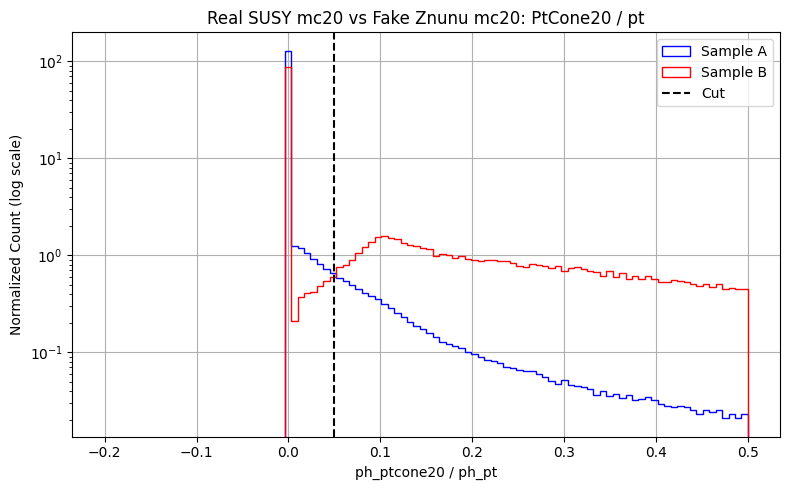

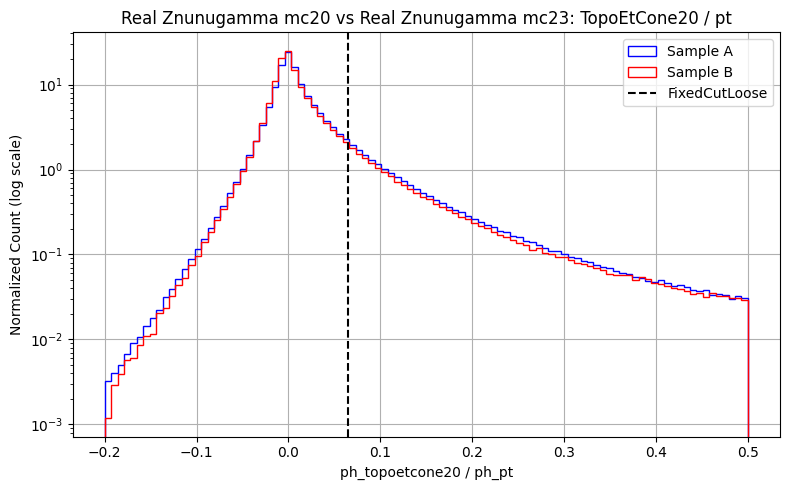

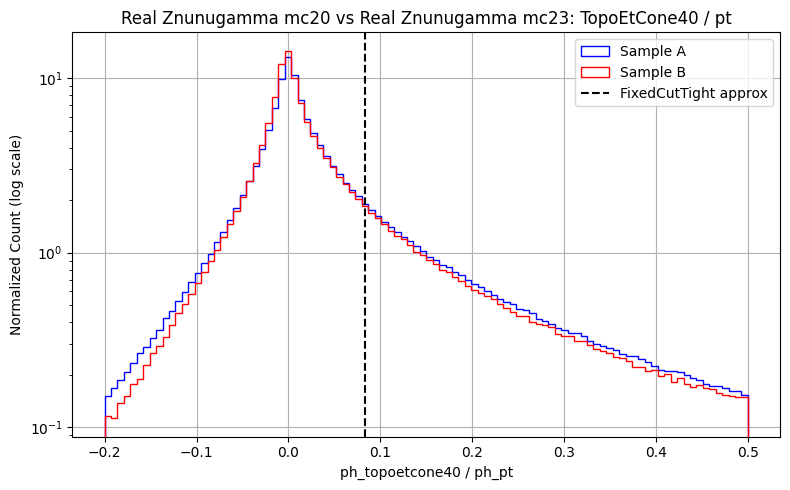

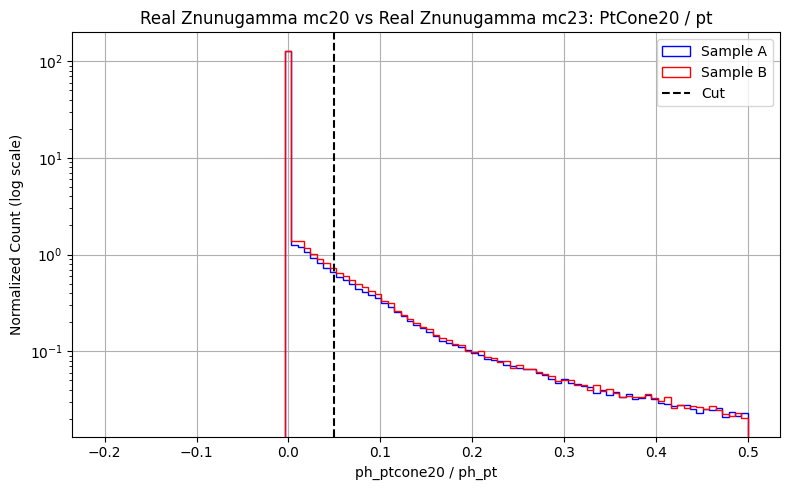

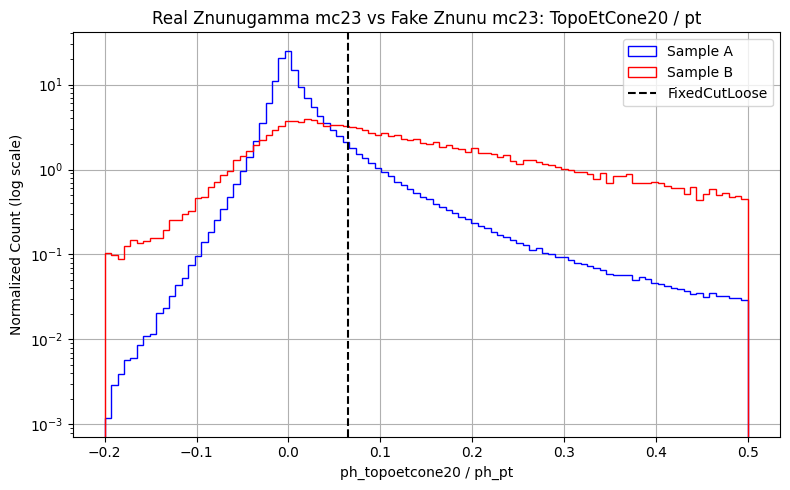

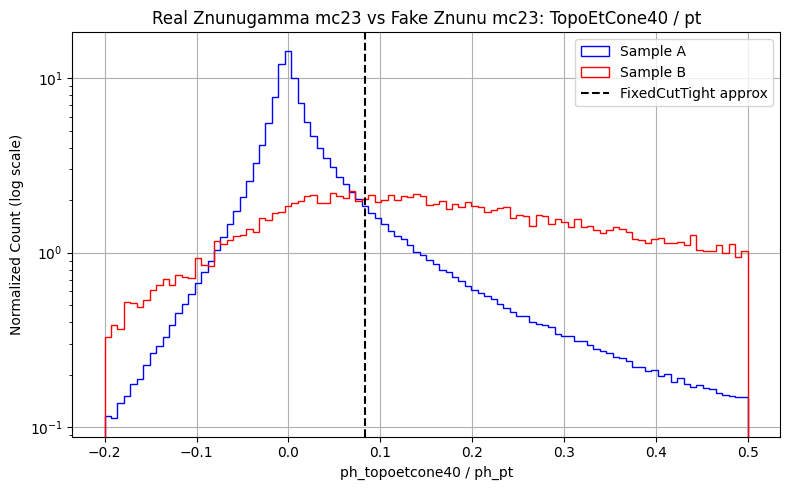

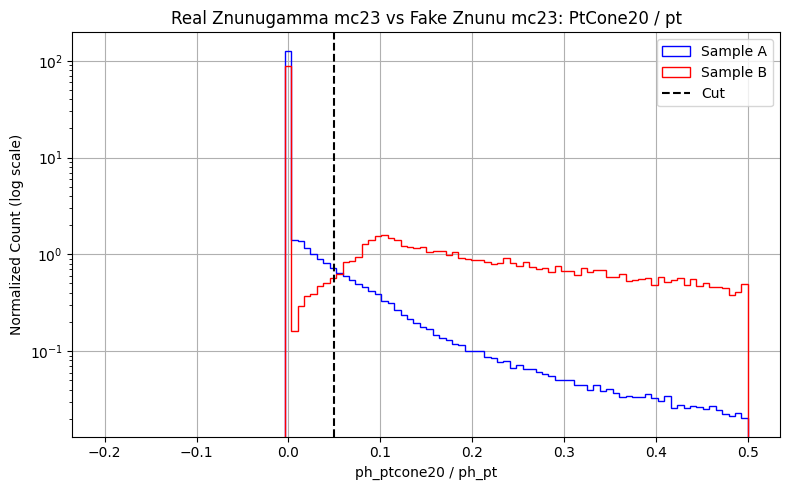

In [13]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# === File paths ===
file_mc20 = "/data/mhance/SUSY/ntuples/v3.1/output_Znunugamma_mc20.root"
file_mc23 = "/data/mhance/SUSY/ntuples/v3.1/output_Sh_2214_nunugamma_mc23.root"

# === Variables to load ===
branches = [
    "ph_pt",
    "ph_topoetcone20",
    "ph_topoetcone40",
    "ph_ptcone20",
    "ph_truthprompt"
]

def load_data(filepath):
    with uproot.open(filepath) as f:
        tree = f["picontuple"]
        return tree.arrays(branches, library="np")

# === Load data ===
data_mc20 = load_data(file_mc20)
data_mc23 = load_data(file_mc23)

# === Define masks ===
real_mc20 = data_mc20["ph_truthprompt"] == 1
fake_mc20 = data_mc20["ph_truthprompt"] == 0
real_mc23 = data_mc23["ph_truthprompt"] == 1
fake_mc23 = data_mc23["ph_truthprompt"] == 0

# === Plot helper ===
def plot_iso(varname, title, data_a, mask_a, label_a, data_b, mask_b, label_b, vlines=None, xmax=0.5, bins=100):
    vals_a = data_a[varname][mask_a] / data_a["ph_pt"][mask_a]
    vals_b = data_b[varname][mask_b] / data_b["ph_pt"][mask_b]

    plt.figure(figsize=(8, 5))
    plt.hist(vals_a, bins=bins, range=(-0.2, xmax), density=True, histtype='step', label=label_a, color='blue')
    plt.hist(vals_b, bins=bins, range=(-0.2, xmax), density=True, histtype='step', label=label_b, color='red')

    if vlines:
        for x, label in vlines:
            plt.axvline(x, linestyle="--", color="black", label=label)

    plt.yscale("log")
    plt.xlabel(f"{varname} / ph_pt")
    plt.ylabel("Normalized Count (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Comparison sets ===
comparisons = [
    ("Fake Znunu mc20 vs Fake Znunu mc23", fake_mc20, data_mc20, fake_mc23, data_mc23),
    ("Real SUSY mc20 vs Fake Znunu mc20", real_mc20, data_mc20, fake_mc20, data_mc20),
    ("Real Znunugamma mc20 vs Real Znunugamma mc23", real_mc20, data_mc20, real_mc23, data_mc23),
    ("Real Znunugamma mc23 vs Fake Znunu mc23", real_mc23, data_mc23, fake_mc23, data_mc23),
]

# === Variables and Cut Lines ===
iso_vars = [
    ("ph_topoetcone20", "TopoEtCone20", [(0.065, "FixedCutLoose")]),
    ("ph_topoetcone40", "TopoEtCone40", [(0.083, "FixedCutTight approx")]),
    ("ph_ptcone20", "PtCone20", [(0.05, "Cut")])
]

# === Generate all plots ===
for title, mask_a, data_a, mask_b, data_b in comparisons:
    for varname, label, cuts in iso_vars:
        plot_iso(varname, f"{title}: {label} / pt", data_a, mask_a, "Sample A", data_b, mask_b, "Sample B", vlines=cuts)


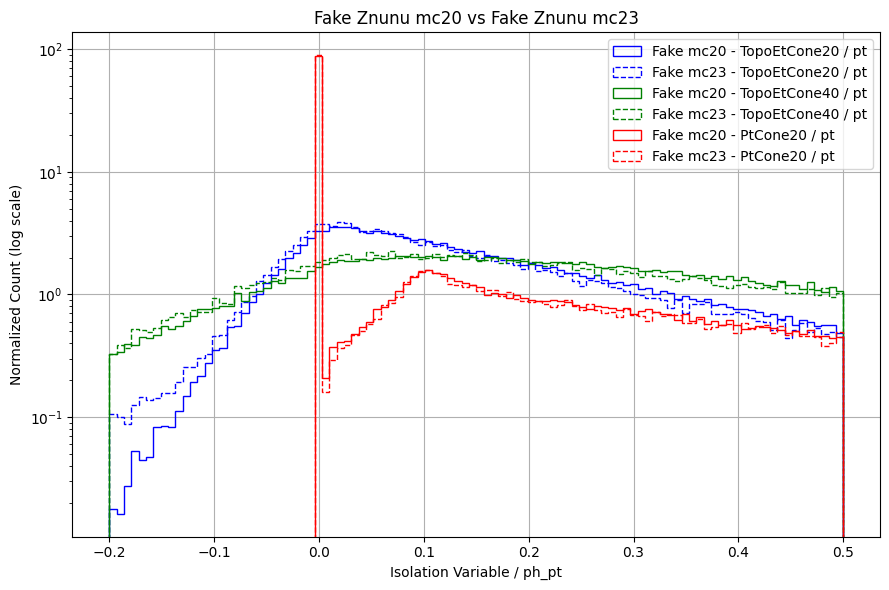

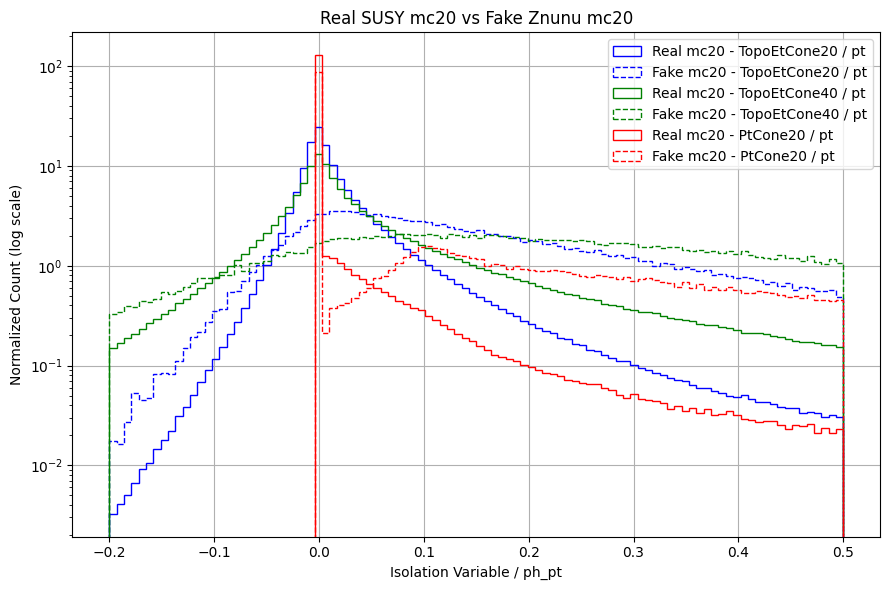

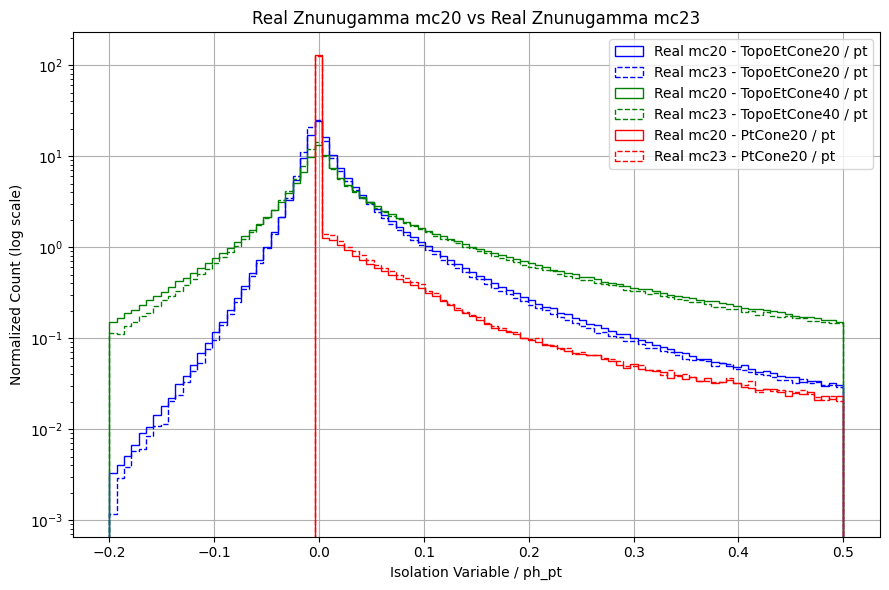

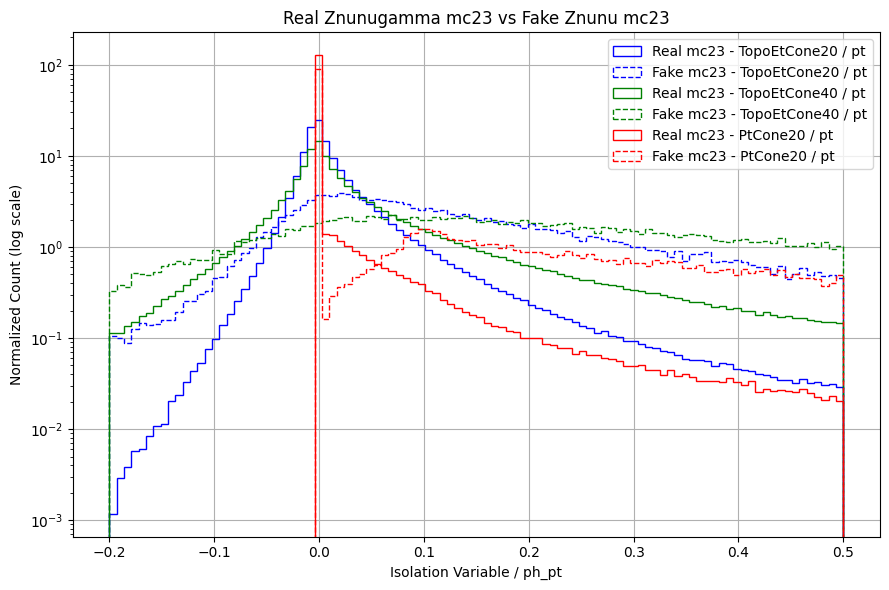

In [14]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# === File paths ===
file_mc20 = "/data/mhance/SUSY/ntuples/v3.1/output_Znunugamma_mc20.root"
file_mc23 = "/data/mhance/SUSY/ntuples/v3.1/output_Sh_2214_nunugamma_mc23.root"

# === Variables to load ===
branches = [
    "ph_pt",
    "ph_topoetcone20",
    "ph_topoetcone40",
    "ph_ptcone20",
    "ph_truthprompt"
]

def load_data(filepath):
    with uproot.open(filepath) as f:
        tree = f["picontuple"]
        return tree.arrays(branches, library="np")

# === Load data ===
data_mc20 = load_data(file_mc20)
data_mc23 = load_data(file_mc23)

# === Define masks ===
real_mc20 = data_mc20["ph_truthprompt"] == 1
fake_mc20 = data_mc20["ph_truthprompt"] == 0
real_mc23 = data_mc23["ph_truthprompt"] == 1
fake_mc23 = data_mc23["ph_truthprompt"] == 0

# === Plotting Function for all iso vars ===
def plot_all_isos(title, data_a, mask_a, label_a, data_b, mask_b, label_b, xmax=0.5, bins=100):
    iso_vars = {
        "ph_topoetcone20": ("TopoEtCone20 / pt", "blue"),
        "ph_topoetcone40": ("TopoEtCone40 / pt", "green"),
        "ph_ptcone20": ("PtCone20 / pt", "red")
    }

    plt.figure(figsize=(9, 6))
    for var, (label, color) in iso_vars.items():
        vals_a = data_a[var][mask_a] / data_a["ph_pt"][mask_a]
        vals_b = data_b[var][mask_b] / data_b["ph_pt"][mask_b]

        plt.hist(vals_a, bins=bins, range=(-0.2, xmax), density=True,
                 histtype='step', label=f"{label_a} - {label}", color=color, linestyle="-")
        plt.hist(vals_b, bins=bins, range=(-0.2, xmax), density=True,
                 histtype='step', label=f"{label_b} - {label}", color=color, linestyle="--")

    plt.yscale("log")
    plt.xlabel("Isolation Variable / ph_pt")
    plt.ylabel("Normalized Count (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Plot Definitions ===
comparisons = [
    ("Fake Znunu mc20 vs Fake Znunu mc23", fake_mc20, data_m c20, fake_mc23, data_mc23, "Fake mc20", "Fake mc23"),
    ("Real SUSY mc20 vs Fake Znunu mc20", real_mc20, data_mc20, fake_mc20, data_mc20, "Real mc20", "Fake mc20"),
    ("Real Znunugamma mc20 vs Real Znunugamma mc23", real_mc20, data_mc20, real_mc23, data_mc23, "Real mc20", "Real mc23"),
    ("Real Znunugamma mc23 vs Fake Znunu mc23", real_mc23, data_mc23, fake_mc23, data_mc23, "Real mc23", "Fake mc23"),
]

# === Generate all overlayed iso plots ===
for title, mask_a, data_a, mask_b, data_b, label_a, label_b in comparisons:
    plot_all_isos(title, data_a, mask_a, label_a, data_b, mask_b, label_b)


[Prompt (signal-like)] pT [10,20] GeV  topoetcone20 / pT: point-biserial r = -0.051
[Prompt (signal-like)] pT [10,20] GeV  topoetcone40 / pT: point-biserial r = -0.032
[Prompt (signal-like)] pT [10,20] GeV  ptcone20 / pT: point-biserial r = -0.010


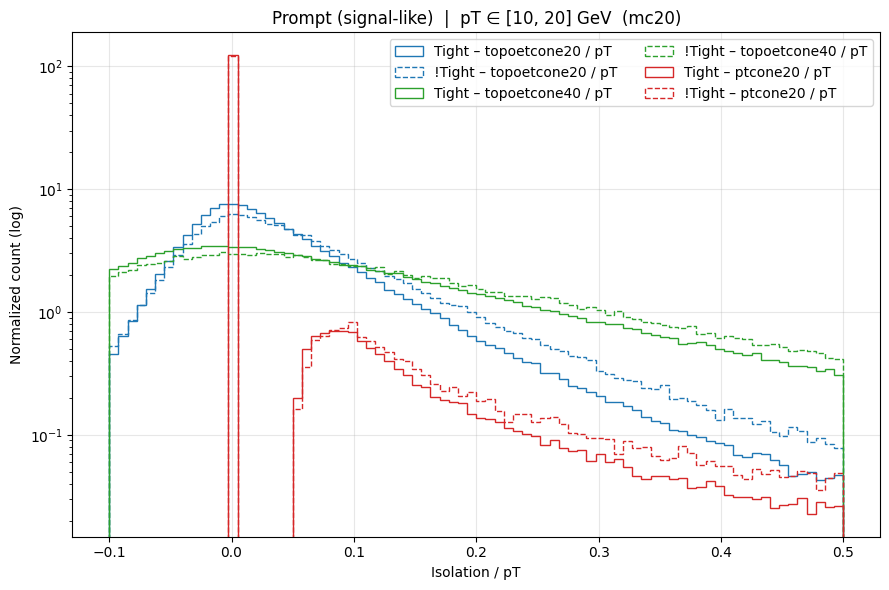

[Prompt (signal-like)] pT [20,40] GeV  topoetcone20 / pT: point-biserial r = -0.089
[Prompt (signal-like)] pT [20,40] GeV  topoetcone40 / pT: point-biserial r = -0.079
[Prompt (signal-like)] pT [20,40] GeV  ptcone20 / pT: point-biserial r = -0.025


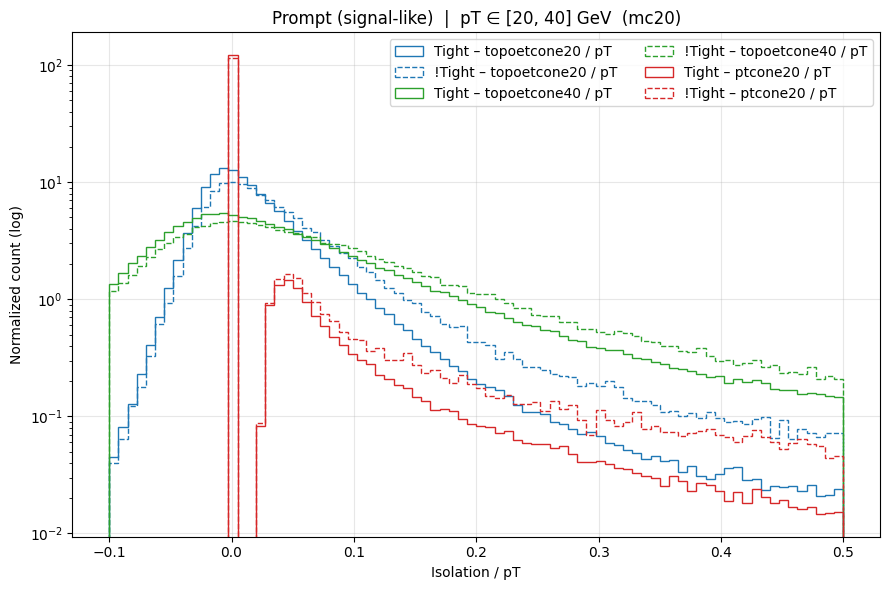

[Prompt (signal-like)] pT [40,80] GeV  topoetcone20 / pT: point-biserial r = -0.158
[Prompt (signal-like)] pT [40,80] GeV  topoetcone40 / pT: point-biserial r = -0.135
[Prompt (signal-like)] pT [40,80] GeV  ptcone20 / pT: point-biserial r = -0.003


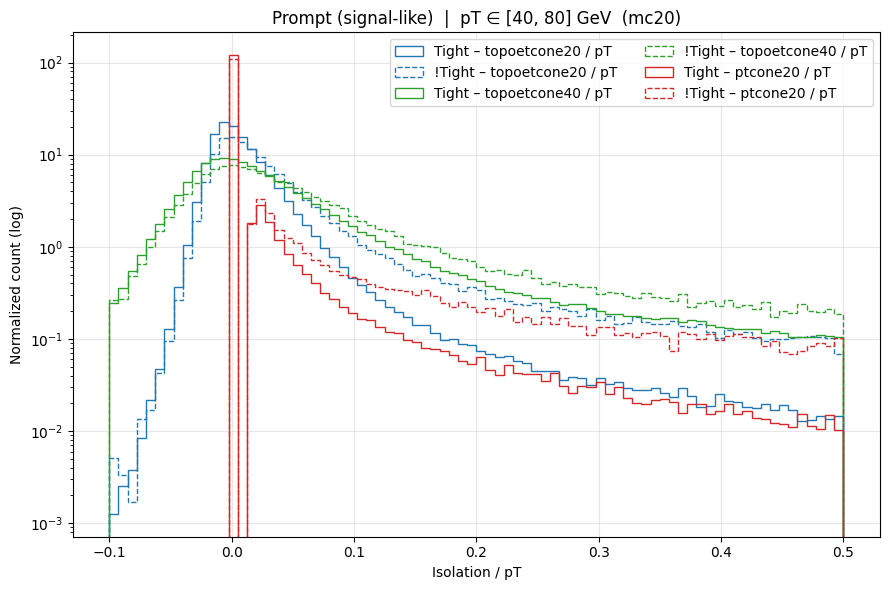

[Prompt (signal-like)] pT [80,1000] GeV  topoetcone20 / pT: point-biserial r = -0.224
[Prompt (signal-like)] pT [80,1000] GeV  topoetcone40 / pT: point-biserial r = -0.175
[Prompt (signal-like)] pT [80,1000] GeV  ptcone20 / pT: point-biserial r = -0.004


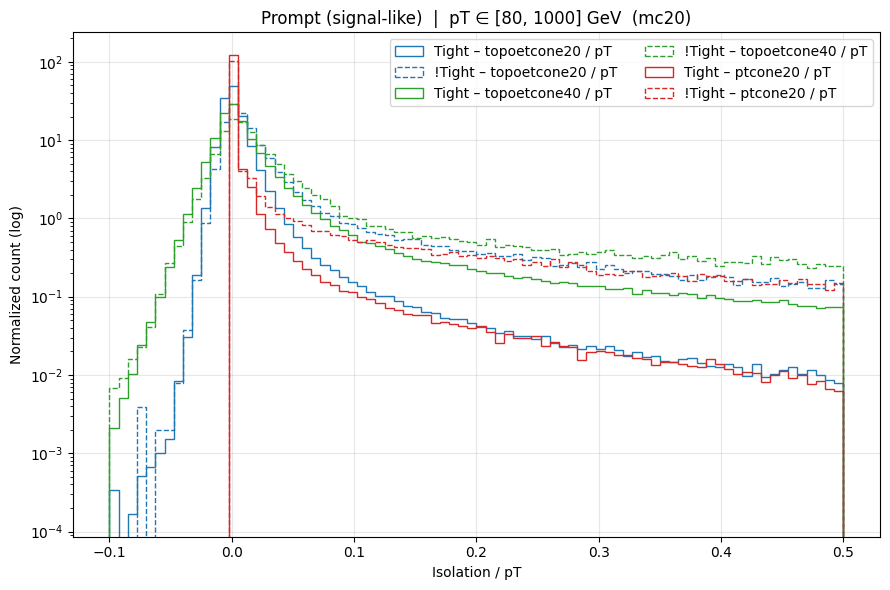

[Jet-fake (JFP)] pT [10,20] GeV  topoetcone20 / pT: point-biserial r = -0.042
[Jet-fake (JFP)] pT [10,20] GeV  topoetcone40 / pT: point-biserial r = -0.024
[Jet-fake (JFP)] pT [10,20] GeV  ptcone20 / pT: point-biserial r = -0.043


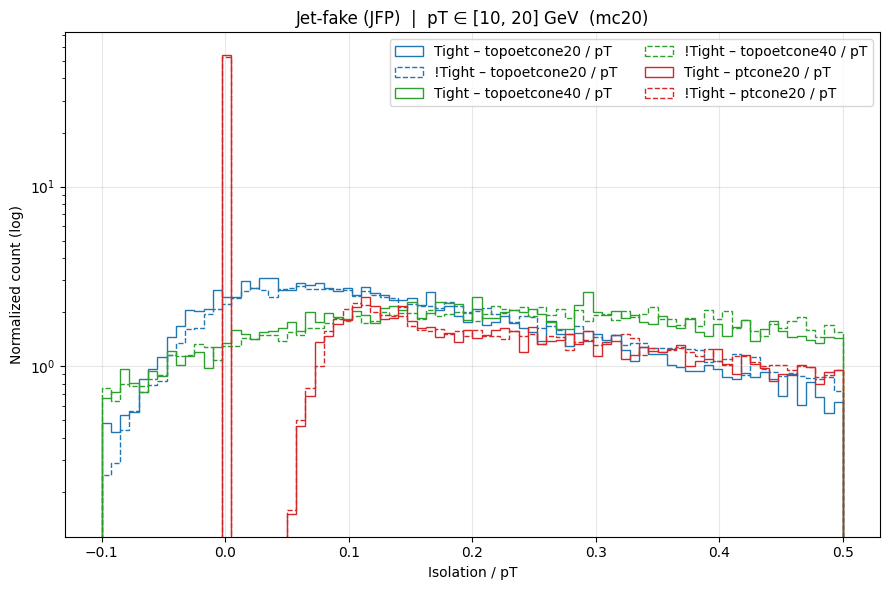

[Jet-fake (JFP)] pT [20,40] GeV  topoetcone20 / pT: point-biserial r = -0.043
[Jet-fake (JFP)] pT [20,40] GeV  topoetcone40 / pT: point-biserial r = -0.021
[Jet-fake (JFP)] pT [20,40] GeV  ptcone20 / pT: point-biserial r = -0.039


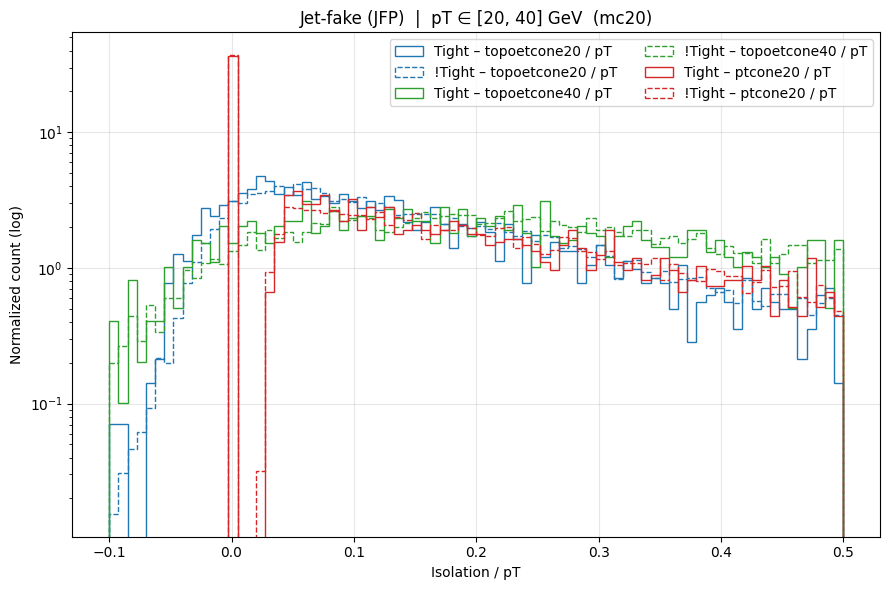

[Jet-fake (JFP)] pT [40,80] GeV  topoetcone20 / pT: point-biserial r = -0.040
[Jet-fake (JFP)] pT [40,80] GeV  topoetcone40 / pT: point-biserial r = -0.031
[Jet-fake (JFP)] pT [40,80] GeV  ptcone20 / pT: point-biserial r = -0.041


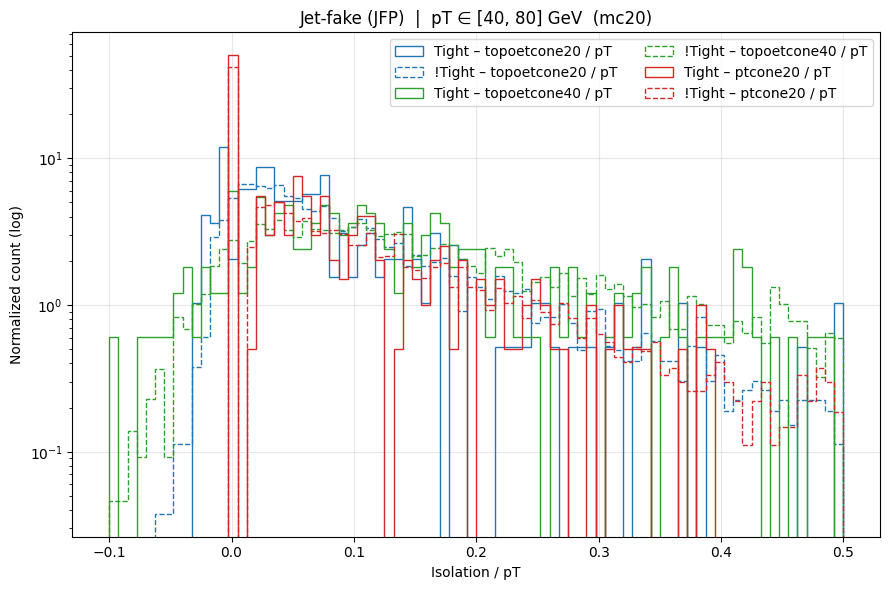

[Jet-fake (JFP)] pT [80,1000] GeV  topoetcone20 / pT: point-biserial r = -0.074
[Jet-fake (JFP)] pT [80,1000] GeV  topoetcone40 / pT: point-biserial r = -0.051
[Jet-fake (JFP)] pT [80,1000] GeV  ptcone20 / pT: point-biserial r = -0.086


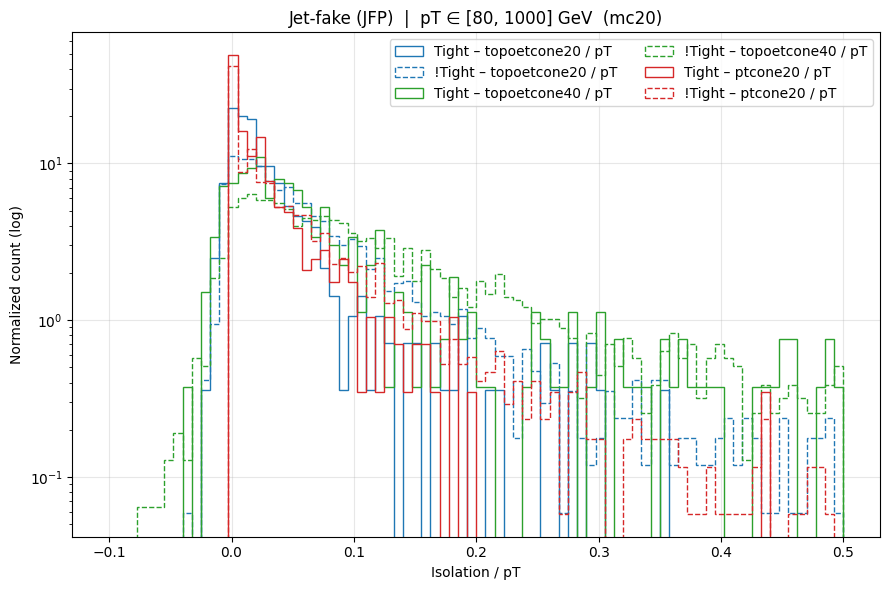

[Electron-fake (EFP)] pT [10,20] GeV  topoetcone20 / pT: point-biserial r = -0.263
[Electron-fake (EFP)] pT [10,20] GeV  topoetcone40 / pT: point-biserial r = -0.127
[Electron-fake (EFP)] pT [10,20] GeV  ptcone20 / pT: point-biserial r = -0.269


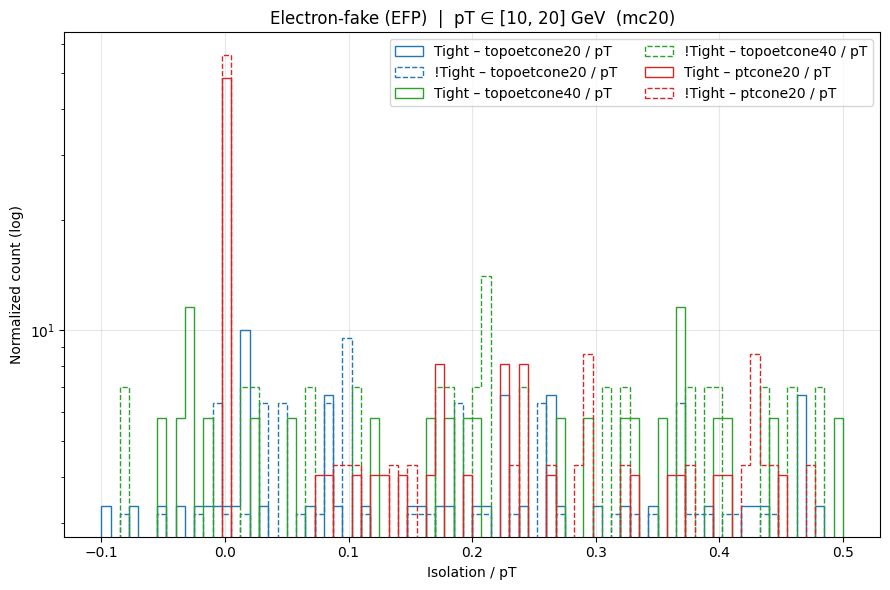

[Electron-fake (EFP)] pT [20,40] GeV  topoetcone20 / pT: point-biserial r = -0.227
[Electron-fake (EFP)] pT [20,40] GeV  topoetcone40 / pT: point-biserial r = -0.032
[Electron-fake (EFP)] pT [20,40] GeV  ptcone20 / pT: point-biserial r = -0.181


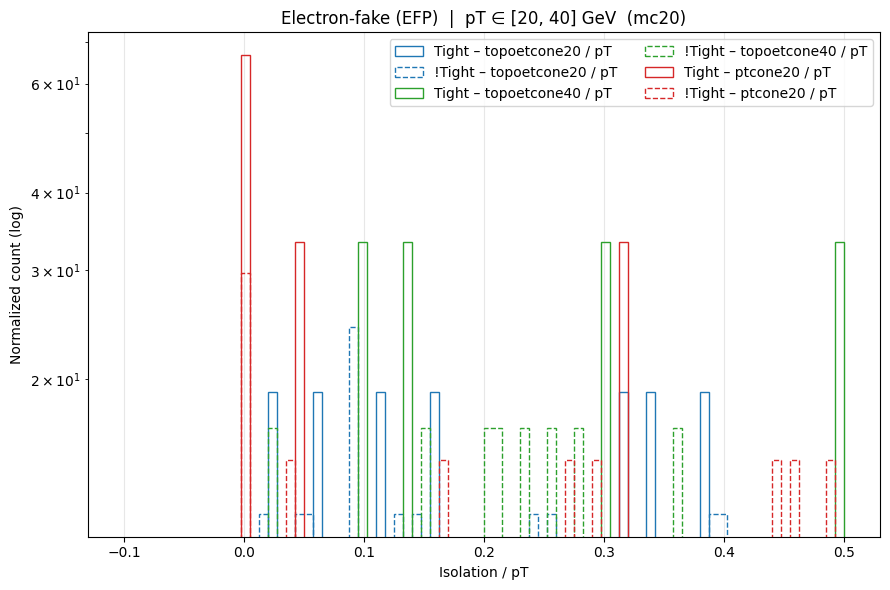

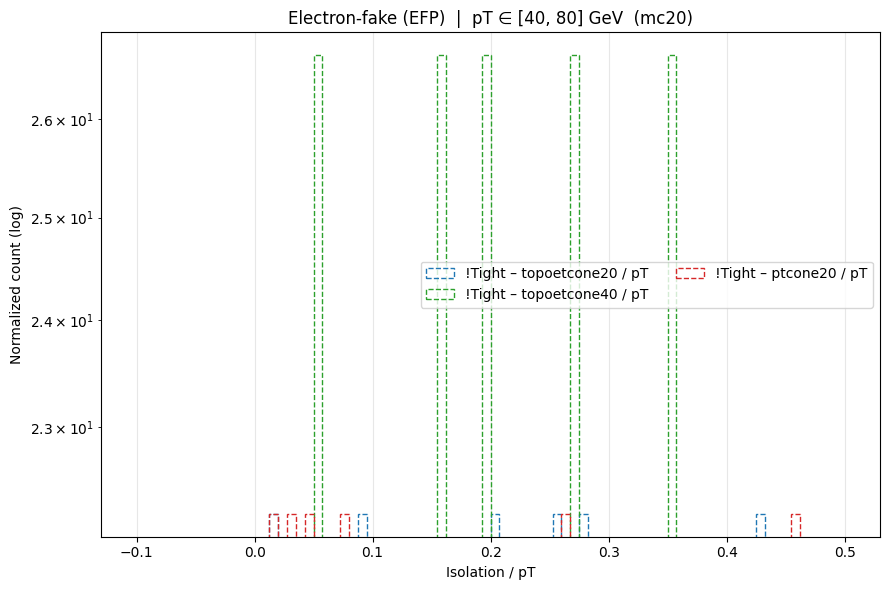

In [3]:
# ---- File (Run 2) ----
FILE = "/data/mhance/SUSY/ntuples/v3.1/output_Znunugamma_mc20.root"

# ---- Branches we need ----
branches = [
    "ph_pt",
    "ph_topoetcone20", "ph_topoetcone40", "ph_ptcone20",
    "ph_select_tightID",
    "ph_truthprompt", "ph_truthJFP", "ph_truthEFP"
]

# ---- Load arrays ----
with uproot.open(FILE) as f:
    tree = f["picontuple"]
    arr = tree.arrays(branches, library="np")

# ---- Define categories from truth labels (mutually informative) ----
cats = {
    "Prompt (signal-like)":          (arr["ph_truthprompt"] == 1),
    "Jet-fake (JFP)":                (arr["ph_truthJFP"] == 1),
    "Electron-fake (EFP)":           (arr["ph_truthEFP"] == 1),
}

# ---- Tight / !Tight masks ----
tight   = (arr["ph_select_tightID"] == 1)
nottight= ~tight

# ---- pT bins (MeV) ----
pt_bins = [(10e3,20e3),(20e3,40e3),(40e3,80e3),(80e3,1e6)]

# ---- Isolation variables to overlay (label, branch, color) ----
isos = [
    ("topoetcone20 / pT", "ph_topoetcone20", "tab:blue"),
    ("topoetcone40 / pT", "ph_topoetcone40", "tab:green"),
    ("ptcone20 / pT",     "ph_ptcone20",     "tab:red"),
]

def point_biserial(iso_vals, tight_flag):
    """
    Simple point-biserial correlation between a continuous ISO and binary tight (0/1).
    Returns np.nan if not enough stats.
    """
    x = iso_vals
    y = tight_flag.astype(float)
    if x.size < 5 or np.unique(y).size < 2:
        return np.nan
    # standard Pearson on (x, y)
    C = np.corrcoef(x, y)
    return C[0,1]

def plot_category(cat_name, cat_mask):
    for (pt_min, pt_max) in pt_bins:
        in_pt = (arr["ph_pt"] >= pt_min) & (arr["ph_pt"] < pt_max)
        sel_tight    = cat_mask & in_pt & tight
        sel_nottight = cat_mask & in_pt & nottight

        # Skip empty bins
        if not np.any(sel_tight) and not np.any(sel_nottight):
            continue

        plt.figure(figsize=(9,6))
        for label, br, color in isos:
            # normalize by pT
            iso_t = arr[br][sel_tight] / arr["ph_pt"][sel_tight]
            iso_nt= arr[br][sel_nottight] / arr["ph_pt"][sel_nottight]

            # Hist: solid = Tight, dashed = !Tight
            if iso_t.size:
                plt.hist(iso_t, bins=80, range=(-0.1,0.5), density=True,
                         histtype="step", color=color, label=f"Tight – {label}")
            if iso_nt.size:
                plt.hist(iso_nt, bins=80, range=(-0.1,0.5), density=True,
                         histtype="step", linestyle="--", color=color, label=f"!Tight – {label}")

            # (Optional) print a simple correlation metric in console
            if (iso_t.size + iso_nt.size) > 10:
                all_iso   = np.concatenate([iso_t, iso_nt]) if iso_nt.size else iso_t
                all_tight = np.concatenate([np.ones_like(iso_t), np.zeros_like(iso_nt)]) if iso_nt.size else np.ones_like(iso_t)
                r_pb = point_biserial(all_iso, all_tight)
                print(f"[{cat_name}] pT [{pt_min/1e3:.0f},{pt_max/1e3:.0f}] GeV  {label}: point-biserial r = {r_pb:0.3f}")

        plt.yscale("log")
        plt.xlabel("Isolation / pT")
        plt.ylabel("Normalized count (log)")
        plt.title(f"{cat_name}  |  pT ∈ [{pt_min/1e3:.0f}, {pt_max/1e3:.0f}] GeV  (mc20)")
        plt.grid(True, alpha=0.3)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

# ---- Run plots for each category from this single mc20 file ----
for cat_name, cat_mask in cats.items():
    plot_category(cat_name, cat_mask)

In [ ]:
A = np.sum((arr['ph_select_tightID'] == True) & (combined_data['ph.topoetcone30'] > 5000))
B = np.sum((arr['ph_select_tightID'] != True) & (combined_data['ph.topoetcone30'] > 5000)) #only checked that not tight bc combined data should have only loose
C = np.sum((arr['ph_select_tightID'] == True) & (combined_data['ph.topoetcone30'] < 5000))
D = np.sum((arr['ph_select_tightID'] != True) & (combined_data['ph.topoetcone30'] < 5000))

print(f"(A) tight & !Iso = {A} ")
print(f"(B) !tight & !Iso = {B} ") 
print(f"(C) tight & Iso = {C} ") 
print(f"(D) !tight & Iso = {D} ") 

C_fake = (A*D) / B
print(f"C_fake = {C_fake} ") 

targetRatio = 1 - (C_fake/C)
print(f"C_real/C = {targetRatio} ") 
print()

uncertainty = math.sqrt( (1/A) + (1/B) + (1/D) ) * C_fake

print(f"N_Cfake : {C_fake} +/- {uncertainty}" )

N_Cfake = C_fake + (uncertainty/2)

purity = 1-(N_Cfake/C)

purity_range = (uncertainty/C_fake)
print(f"purity = {purity} +/- {purity_range}")

In [16]:
#FILE = "/data/mhance/SUSY/ntuples/v3.1/output_Znunugamma_mc20.root"
FILE = "/data/mhance/SUSY/ntuples/v3.1/output_Znunu_CVetoBVeto_mc20.root"




BRANCHES = [
    "ph_pt",
    "ph_topoetcone20","ph_topoetcone40","ph_ptcone20",
    "ph_select_tightID",
    "ph_truthprompt","ph_truthJFP", "ph_isEM"
]

with uproot.open(FILE) as f:
    arr = f["picontuple"].arrays(BRANCHES, library="np")


looseprime = ((ph_isEM & 0x45fc01)==0)

arr = arr["loosprime"]

pt      = arr["ph_pt"]
topo20  = arr["ph_topoetcone20"]
topo40  = arr["ph_topoetcone40"]
ptc20   = arr["ph_ptcone20"]
tight   = (arr["ph_select_tightID"] == 1)


##########   !tight (tb applied over all the data) = (ph_isEM & 0x45fc01)==0 [ or  looseprime = ((ph_isEM & 0x45fc01)==0) ]


truth_prompt = (arr["ph_truthprompt"] == 1)
truth_fake   = (arr["ph_truthJFP"] == 1) | (arr["ph_truthEFP"] == 1)

## ATLAS ISO CUTS ##
def iso_mask_fixedcutloose():
    return (topo20 < 0.065*pt) & ((ptc20/pt) < 0.05)

def iso_mask_fixedcuttight():
    return (topo40 < (0.022*pt + 2.45)) & ((ptc20/pt) < 0.05)

def iso_mask_tightcaloonly():
    return (topo40 < (0.022*pt + 2.45))

    

def abcd_prompt_subtracted(iso_mask, extra_sel=None, label=""):
    sel = np.ones_like(tight, dtype=bool) if extra_sel is None else extra_sel
    Iso    =  iso_mask & sel
    NotIso = ~iso_mask & sel

    # all
    A_tot = np.sum( tight & NotIso)
    B_tot = np.sum(~tight & NotIso)
    C_tot = np.sum( tight &  Iso  )
    D_tot = np.sum(~tight &  Iso  )

    # prompt leak
    A_pr  = np.sum( truth_prompt & tight & NotIso)
    B_pr  = np.sum( truth_prompt & ~tight & NotIso)
    D_pr  = np.sum( truth_prompt & ~tight &  Iso  )
    C_pr =  np.sum( truth_prompt & tight &  Iso  )

    A_bg = max ( A_tot - A_pr, 0)
    B_bg = max ( B_tot - B_pr, 0)
    D_bg = max ( D_tot - D_pr, 0)
    C_bg = mac ( C_tot - C_pr, 0)

    print("ratio: ", (A_bg/B_bg)/(C_bg/D_bg))
    

    # --- uncertainties on bg counts (Poisson, subtraction of independent Poissons) ---
    #sigA = math.sqrt(A_tot + A_pr)
    #sigB = math.sqrt(B_tot + B_pr)
    #sigD = math.sqrt(D_tot + D_pr)

    # --- ABCD prediction using prompt-subtracted control regions ---
    C_fake_pred = np.nan
    C_fake_err  = np.nan

    C_fake_pred = (A_bg * D_bg) / B_bg
    # Error propagation for C = A*D/B
    dCdA = D_bg / B_bg
    dCdD = A_bg / B_bg
    dCdB = -(A_bg * D_bg) / (B_bg**2)
    varC = (dCdA**2) * (sigA**2) + (dCdD**2) * (sigD**2) + (dCdB**2) * (sigB**2)
    C_fake_err = math.sqrt(varC)

    # --- truth in C for closure ---
    C_true_fake = np.sum(truth_fake   & tight & Iso)
    C_true_real = np.sum(truth_prompt & tight & Iso)

    print((A_bg/B_bg)/(C_fake_pred/D_bg))

    purity_truth = np.nan
    purity_truth_err = np.nan
    if C_tot > 0:
        fake_frac = C_true_fake / C_tot
        purity_truth = 1.0 - fake_frac
        purity_truth_err = math.sqrt(fake_frac*(1-fake_frac)/C_tot)

    purity_abcd = np.nan
    purity_abcd_err = np.nan
    if C_tot > 0 and np.isfinite(C_fake_pred):
        purity_abcd = 1.0 - (C_fake_pred / C_tot)
        purity_abcd_err = (C_fake_err / C_tot) if np.isfinite(C_fake_err) else np.nan

    return dict(
        label=label,
        A_tot=int(A_tot), B_tot=int(B_tot), C_tot=int(C_tot), D_tot=int(D_tot),
        A_prompt=int(A_pr), B_prompt=int(B_pr), D_prompt=int(D_pr),
        A_bg=int(A_bg), B_bg=int(B_bg), D_bg=int(D_bg),
        C_fake_pred=C_fake_pred, C_fake_err=C_fake_err,
        C_true_fake=int(C_true_fake), C_true_real=int(C_true_real),
        purity_truth=purity_truth, purity_truth_err=purity_truth_err,
        purity_abcd=purity_abcd, purity_abcd_err=purity_abcd_err,
    )

def pretty_print(res):
    print(f"[{res['label']}]")
    print(f"  Totals   : A={res['A_tot']}  B={res['B_tot']}  C={res['C_tot']}  D={res['D_tot']}")
    print(f"  Prompt   : A={res['A_prompt']}  B={res['B_prompt']}  D={res['D_prompt']}")
    print(f"  Bg-only  : A={res['A_bg']}  B={res['B_bg']}  D={res['D_bg']}")
    print(f"  ABCD pred C_fake = {res['C_fake_pred']:.3f} ± {res['C_fake_err']:.3f}")
    print(f"  Truth in C: fake={res['C_true_fake']}  real={res['C_true_real']}")
    print(f"  Purity (truth) = {res['purity_truth']:.3f} ± {res['purity_truth_err']:.3f}")
    print(f"  Purity (ABCD ) = {res['purity_abcd']:.3f} ± {res['purity_abcd_err']:.3f}")
    if np.isfinite(res['purity_truth']) and np.isfinite(res['purity_abcd']):
        print(f"  Closure Δ = ABCD − truth = {res['purity_abcd'] - res['purity_truth']:+.3f}")
    print()

# ---- Run for each ATLAS working point (inclusive) ----
for name, fun in [
    ("FixedCutLoose",  iso_mask_fixedcutloose),
    ("FixedCutTight",  iso_mask_fixedcuttight),
    ("TightCaloOnly",  iso_mask_tightcaloonly),
]:
    r = abcd_prompt_subtracted(fun(), label=name)
    pretty_print(r)

ratio:  0.708194604232841
1.0
[FixedCutLoose]
  Totals   : A=93016  B=287210  C=36362  D=79504
  Prompt   : A=55  B=286  D=88
  Bg-only  : A=92961  B=286924  D=79416
  ABCD pred C_fake = 25730.126 ± 133.405
  Truth in C: fake=9622  real=30
  Purity (truth) = 0.735 ± 0.002
  Purity (ABCD ) = 0.292 ± 0.004
  Closure Δ = ABCD − truth = -0.443

ratio:  0.7073912741478429
1.0
[FixedCutTight]
  Totals   : A=109992  B=326075  C=19386  D=40639
  Prompt   : A=70  B=341  D=33
  Bg-only  : A=109922  B=325734  D=40606
  ABCD pred C_fake = 13702.876 ± 83.185
  Truth in C: fake=4270  real=15
  Purity (truth) = 0.780 ± 0.003
  Purity (ABCD ) = 0.293 ± 0.004
  Closure Δ = ABCD − truth = -0.487

ratio:  0.718338031684547
1.0000000000000002
[TightCaloOnly]
  Totals   : A=106241  B=317119  C=23137  D=49595
  Prompt   : A=68  B=332  D=42
  Bg-only  : A=106173  B=316787  D=49553
  ABCD pred C_fake = 16607.975 ± 95.128
  Truth in C: fake=7321  real=17
  Purity (truth) = 0.684 ± 0.003
  Purity (ABCD ) = 0.28

In [3]:
# --- ABCD quick report: totals, ABCD prediction, and truth purity ---
import numpy as np
import math
import uproot

# -------------------------
# 1) Load arrays you need
# -------------------------
FILE = "/data/mhance/SUSY/ntuples/v3.1/output_Znunugamma_mc20.root"
BRANCHES = [
    "ph_pt","ph_eta",
    "ph_topoetcone20","ph_topoetcone40","ph_ptcone20",
    "ph_select_tightID",
    "ph_truthprompt","ph_truthJFP","ph_truthEFP","ph_isEM"
]

with uproot.open(FILE) as f:
    arr = f["picontuple"].arrays(BRANCHES, library="np")


pt      = arr["ph_pt"]
eta     = arr["ph_eta"]
topo20  = arr["ph_topoetcone20"]
topo40  = arr["ph_topoetcone40"]
ptc20   = arr["ph_ptcone20"]

tight   = (arr["ph_select_tightID"] == 1)
prompt  = (arr["ph_truthprompt"] == 1)      # "real" photons
nonprompt = ~prompt                          # for truth "fake" fraction

# LoosePrime mask (apply to EVERY selection)
looseprime = ((arr["ph_isEM"] & 0x45fc01) == 0)

# --------------------------------------------------------
# 4) Isolation masks (ATLAS recommended working points)
# --------------------------------------------------------
def iso_mask_fixedcutloose():
    # topoetcone20 < 0.065 * pT  &&  ptcone20/pT < 0.05
    return (topo20 < 0.065*pt) & ((ptc20 / np.maximum(pt, 1e-12)) < 0.05)

def iso_mask_fixedcuttight():
    # topoetcone40 < 0.022 * pT + 2.45  &&  ptcone20/pT < 0.05
    return (topo40 < (0.022*pt + 2.45)) & ((ptc20 / np.maximum(pt, 1e-12)) < 0.05)

def iso_mask_tightcaloonly():
    # topoetcone40 < 0.022 * pT + 2.45
    return (topo40 < (0.022*pt + 2.45))

def get_iso_mask(wp_name: str):
    wp_name = wp_name.lower()
    if wp_name in ("fixedcutloose","loose","fcl"):
        return iso_mask_fixedcutloose(), "FixedCutLoose"
    elif wp_name in ("fixedcuttight","tight","fct"):
        return iso_mask_fixedcuttight(), "FixedCutTight"
    elif wp_name in ("tightcaloonly","tco"):
        return iso_mask_tightcaloonly(), "TightCaloOnly"
    else:
        raise ValueError(f"Unknown WP '{wp_name}'")

# -----------------------------------------------------------------
# 5) Core function: compute ABCD counts and purities (neat report)
# -----------------------------------------------------------------
def abcd_report(wp="fixedcuttight", pt_range=None, eta_range=None,
                use_simple_uncert=True):
    """
    - Applies LoosePrime globally
    - Optionally applies pT and |eta| ranges
    - Builds A,B,C,D
    - Subtracts prompt from A/B/D (as in your slide)
    - Prints totals, predicted purity (ABCD), and truth purity in C
    """
    Iso, wp_label = get_iso_mask(wp)
    base = looseprime.copy()

    # Optional kinematic slice
    if pt_range is not None:
        lo, hi = pt_range
        base &= (pt >= lo) & (pt < hi)
    if eta_range is not None:
        lo, hi = eta_range
        base &= (np.abs(eta) >= lo) & (np.abs(eta) < hi)

    # Regions
    Iso_m    =  Iso     & base
    NotIso_m = (~Iso)   & base
    Tight_m  =  tight   & base
    NotT_m   = (~tight) & base

    # Totals (before subtraction)
    A_tot = int(np.sum(Tight_m  & NotIso_m))   # Tight & !Iso
    B_tot = int(np.sum(NotT_m   & NotIso_m))   # !Tight & !Iso
    C_tot = int(np.sum(Tight_m  &  Iso_m))     # Tight & Iso
    D_tot = int(np.sum(NotT_m   &  Iso_m))     # !Tight & Iso

    # Prompt leakage in controls
    A_pr  = int(np.sum(prompt & Tight_m  & NotIso_m))
    B_pr  = int(np.sum(prompt & NotT_m   & NotIso_m))
    D_pr  = int(np.sum(prompt & NotT_m   &  Iso_m))

    # Background-only controls
    A_bg = max(A_tot - A_pr, 0)
    B_bg = max(B_tot - B_pr, 0)
    D_bg = max(D_tot - D_pr, 0)

    # ABCD prediction for fake in C
    C_fake_pred = float("nan")
    C_fake_err  = float("nan")
    if B_bg > 0 and A_bg >= 0 and D_bg >= 0:
        C_fake_pred = (A_bg * D_bg) / B_bg

        if use_simple_uncert:
            # Simple uncertainty you requested: sqrt(1/A + 1/B + 1/D) * C_fake
            if A_bg > 0 and D_bg > 0:
                C_fake_err = math.sqrt((1/A_bg) + (1/B_bg) + (1/D_bg)) * C_fake_pred
        else:
            # Rigorous propagation with Poisson subtraction (optional)
            sigA = math.sqrt(A_tot + A_pr)
            sigB = math.sqrt(B_tot + B_pr)
            sigD = math.sqrt(D_tot + D_pr)
            dCdA = D_bg / B_bg
            dCdD = A_bg / B_bg
            dCdB = -(A_bg * D_bg) / (B_bg**2)
            varC = (dCdA**2)*(sigA**2) + (dCdD**2)*(sigD**2) + (dCdB**2)*(sigB**2)
            C_fake_err = math.sqrt(max(varC, 0.0))

    # Truth composition in C (for sanity)
    C_prompt = int(np.sum(prompt    & Tight_m & Iso_m))
    C_fakeNP = int(np.sum(nonprompt & Tight_m & Iso_m))  # everything not prompt
    # Breakdown if you want to see JFP/EFP specifically:
    C_jfp = int(np.sum(fake_j & Tight_m & Iso_m))
    C_efp = int(np.sum(fake_e & Tight_m & Iso_m))

    # Purities
    purity_abcd = float("nan")
    purity_abcd_err = float("nan")
    if C_tot > 0 and np.isfinite(C_fake_pred):
        purity_abcd = 1.0 - (C_fake_pred / C_tot)
        purity_abcd_err = (C_fake_err / C_tot) if np.isfinite(C_fake_err) else float("nan")

    purity_truth = float("nan")
    purity_truth_err = float("nan")
    if C_tot > 0:
        p = C_prompt / C_tot
        purity_truth = p
        purity_truth_err = math.sqrt(max(p*(1-p)/C_tot, 0.0))

    # Pretty print
    hdr = f"ABCD REPORT  |  WP = {wp_label}"
    if pt_range:  hdr += f"  |  pT∈[{pt_range[0]}, {pt_range[1]}] GeV"
    if eta_range: hdr += f"  |  |eta|∈[{eta_range[0]}, {eta_range[1]}]"
    print("\n" + hdr)
    print("-"*len(hdr))
    print(f"{'Totals':<10}: A={A_tot:>6}  B={B_tot:>6}  C={C_tot:>6}  D={D_tot:>6}")
    print(f"{'Prompt':<10}: A={A_pr:>6}  B={B_pr:>6}  C={C_prompt:>6}  D={D_pr:>6}")
    print(f"{'Bg-only':<10}: A={A_bg:>6}  B={B_bg:>6}            D={D_bg:>6}")
    print(f"{'ABCD C_fake':<10}: {C_fake_pred:>10.3f}  ± {C_fake_err:<10.3f}")
    print(f"{'Truth in C':<10}: prompt={C_prompt:>6}  nonprompt={C_fakeNP:>6}  (jfp={C_jfp}, efp={C_efp})")
    print(f"{'Purity(ABCD)':<10}: {purity_abcd:>8.3f}  ± {purity_abcd_err:<6.3f}")
    print(f"{'Purity(truth)':<10}: {purity_truth:>8.3f}  ± {purity_truth_err:<6.3f}")

    return dict(
        wp=wp_label,
        A_tot=A_tot, B_tot=B_tot, C_tot=C_tot, D_tot=D_tot,
        A_prompt=A_pr, B_prompt=B_pr, D_prompt=D_pr, C_prompt=C_prompt,
        A_bg=A_bg, B_bg=B_bg, D_bg=D_bg,
        C_fake_pred=C_fake_pred, C_fake_err=C_fake_err,
        purity_abcd=purity_abcd, purity_abcd_err=purity_abcd_err,
        purity_truth=purity_truth, purity_truth_err=purity_truth_err,
        C_nonprompt=C_fakeNP, C_jfp=C_jfp, C_efp=C_efp,
    )

# -------------------------
# 6) Run and print neatly
# -------------------------
# Choose WP: "fixedcutloose" / "fixedcuttight" / "tightcaloonly"
res = abcd_report(wp="fixedcuttight", pt_range=None, eta_range=None, use_simple_uncert=True)

# If you want to loop over pT bins:
# for lo, hi in [(10,20),(20,40),(40,80)]:
#     abcd_report(wp="fixedcuttight", pt_range=(lo,hi), eta_range=None, use_simple_uncert=True)


NameError: name 'fake_j' is not defined

In [27]:
##### Code to create different looseprimes

import numpy as np

# ---- 1) Bit positions from egammaPIDdefs.h (only the ones we need here) ----
BIT = {
    "ClusterEtaRange_Photon":         0,   # (sometimes included in PhotonLoose)
    "ClusterHadronicLeakage_Photon": 10,   # Rhad
    "ClusterMiddleEnergy_Photon":    11,   # E277
    "ClusterMiddleEratio37_Photon":  12,   # Reta (common)
    "ClusterMiddleEratio33_Photon":  13,   # Reta alt
    "ClusterMiddleWidth_Photon":     14,   # Weta2
    "ClusterStripsEratio_Photon":    15,   # Eratio (strips)
    "ClusterStripsDeltaEmax2_Photon":16,   # DeltaEmax2
    "ClusterStripsDeltaE_Photon":    17,   # DeltaE
    "ClusterStripsWtot_Photon":      18,   # Wstot
    "ClusterStripsDEmaxs1_Photon":   21,   # DEmaxs1
    "TrackMatchEoverP_Photon":       22,   # (not usually used for photons)
    # there are more bits defined in the header; add if you need them
}

def mask_of(names):
    """Build a bit mask from a list of bit-name strings."""
    m = 0
    for name in names:
        m |= (1 << BIT[name])
    return m

# Base PhotonLoose m'ask (Run-2: Rhad, E277, Reta, Weta2) ----
# Reta can be bit 12 or 13 depending on selector configuration using 12 for now
def photon_loose_mask(use_eta_ratio_bit=12, include_eta_range=False):
    names = [
        "ClusterHadronicLeakage_Photon",  # 10 = Rhad
        "ClusterMiddleEnergy_Photon",     # 11 = E277
        "ClusterMiddleWidth_Photon",      # 14 = Weta2
    ]
    if use_eta_ratio_bit == 12:
        names.append("ClusterMiddleEratio37_Photon")
    else:
        names.append("ClusterMiddleEratio33_Photon")

    if include_eta_range:  # some definitions include bit 0, some don't
        names.append("ClusterEtaRange_Photon")

    return mask_of(names)

# ---- 3) LoosePrime variants (compose from PhotonLoose + extra strips bits) ----
def build_looseprime_masks(
    use_eta_ratio_bit=12,
    include_eta_range=False
):
    PL = photon_loose_mask(use_eta_ratio_bit, include_eta_range)

    # Convenience aliases
    Eratio     = "ClusterStripsEratio_Photon"
    DEmx2      = "ClusterStripsDeltaEmax2_Photon"
    DeltaE     = "ClusterStripsDeltaE_Photon"
    Wstot      = "ClusterStripsWtot_Photon"
    DEmaxs1    = "ClusterStripsDEmaxs1_Photon"

    masks = {}

    # PhotonLoosePrime2: PhotonLoose + {DeltaEmax2, Eratio, Wstot, DEmaxs1, DeltaE}
    masks["PhotonLoosePrime2"] = PL | mask_of([DEmx2, Eratio, Wstot, DEmaxs1, DeltaE])

    # PhotonLoosePrime3: PhotonLoose + {DeltaEmax2, Eratio, Wstot, DEmaxs1}   (minus DeltaE)
    masks["PhotonLoosePrime3"] = PL | mask_of([DEmx2, Eratio, Wstot, DEmaxs1])

    # LoosePrime4:
    # Notes say: "All tight cuts, minus Ws3, Fside, DeltaE, Eratio."
    # -> include DeltaEmax2 and Wstot; EXCLUDE DeltaE, Eratio, Ws3, Fside.
    lp4_bits = [DEmx2, Wstot, Eratio]
    masks["LoosePrime4"] = PL | mask_of(lp4_bits)

    # LoosePrime4a:
    # Notes: "minus Ws3, Fside, DeltaE, Wstot" (alternative when triggers cut on Eratio)
    # -> include DeltaEmax2 and DEmaxs1; optionally include Eratio depending on your trigger.
    masks["LoosePrime4a"] = PL | mask_of([DEmx2, Eratio, DEmaxs1])

    # LoosePrime5:
    # Notes: "minus Ws3, Fside, DeltaE, Wstot, Eratio" -> keep only DeltaEmax2 from the strips group.
    lp5_bits = [DEmx2, Eratio]
    masks["LoosePrime5"] = PL | mask_of(lp5_bits)

    masks["Run1"]=0x45fc01

    return masks

# Check to see if photon passes specific mask
def passes(mask, isEM):
    """Return boolean array: True if photon passes the 'LoosePrimeX' mask."""
    return (isEM & mask) == 0


In [28]:
import numpy as np
import uproot
import math

FILE = "/data/mhance/SUSY/ntuples/v3.1/output_Znunu_CVetoBVeto_mc20.root"
BRANCHES = [
    "ph_pt", "ph_eta", "ph_topoetcone20", "ph_topoetcone40", "ph_ptcone20",
    "ph_select_tightID", "ph_truthprompt", "ph_isEM",
    "met_met", "jet_cleanTightBad_prod", "j1_pt", "mindPhiJetMet",
    "nBTagJets", "nElectrons", "nMuons", "weight_total"
]

with uproot.open(FILE) as f:
    arr = f["picontuple"].arrays(BRANCHES, library="np")

# Scalars/arrays we’ll use
pt      = arr["ph_pt"].astype(float)
eta     = arr["ph_eta"].astype(float)
topo20  = arr["ph_topoetcone20"].astype(float)
topo40  = arr["ph_topoetcone40"].astype(float)
ptc20   = arr["ph_ptcone20"].astype(float)
tight   = (arr["ph_select_tightID"] == 1)
prompt  = (arr["ph_truthprompt"]   == 1)
isEM    = arr["ph_isEM"].astype(np.uint32)

met_met            = arr["met_met"].astype(float)
jet_cleanTightBad  = arr["jet_cleanTightBad_prod"].astype(np.int32)
j1_pt              = arr["j1_pt"].astype(float)
mindPhiJetMet      = arr["mindPhiJetMet"].astype(float)
nBTagJets          = arr["nBTagJets"].astype(np.int32)
nElectrons         = arr["nElectrons"].astype(np.int32)
nMuons             = arr["nMuons"].astype(np.int32)

w = arr["weight_total"].astype(float)


### TOTAL mask for event selection
abs_eta = np.abs(eta)
eta_ok  = (abs_eta < 2.37) & ~((abs_eta > 1.37) & (abs_eta < 1.52))

pt_ok   = (pt > 10000.0)

evt_ok = (
    (met_met > 200000.0) &
    (jet_cleanTightBad == 1) &
    (j1_pt > 150000.0) &
    (mindPhiJetMet > 0.4) &
    (nBTagJets == 0) &
    (nElectrons == 0) &
    (nMuons == 0)
)

TOT_mask = eta_ok & pt_ok & evt_ok

# First we tried LoosePrime mask (apply to ALL selections)
looseprime = ((arr["ph_isEM"] & 0x45fc01) == 0)
fc_mask = looseprime 

# -------------------------
# 1) ISO mask ATLAS 
# -------------------------
def iso_mask_fixedcutloose(pt, topo20, ptc20):
    # topoetcone20 < 0.065*pt  AND  ptcone20/pt < 0.05
    return (topo20 < 0.065 * pt) & ((ptc20 / pt) < 0.05)

def iso_mask_fixedcuttight(pt, topo40, ptc20):
    # topoetcone40 < 0.022*pt + 2.45  AND  ptcone20/pt < 0.05
    return (topo40 < (0.022 * pt + 2.45)) & ((ptc20 / pt) < 0.05)

def iso_mask_tightcaloonly(pt, topo40):
    # topoetcone40 < 0.022*pt + 2.45
    return (topo40 < (0.022 * pt + 2.45))

# -------------------------
# 2) ABCD 
# -------------------------
def abcd_counts(iso, looseMask):
    """
    iso: boolean array (True = isolated)
    A: tight & !iso  (background-only via truth veto)
    B: !tight & !iso (background-only)
    C: tight &  iso  (TOTAL signal-region count)
    D: !tight &  iso (background-only)
    """
    A = np.sum(TOT_mask & looseMask &  tight & ~iso & ~prompt)
    B = np.sum(TOT_mask & looseMask & ~tight & ~iso & ~prompt)
    C = np.sum(TOT_mask & looseMask &  tight &  iso)          
    D = np.sum(TOT_mask & looseMask & ~tight &  iso & ~prompt)

    C_fake = (A * D) / B if B > 0 else np.nan
    purity = 1 - (C_fake / C) if (C > 0 and np.isfinite(C_fake)) else np.nan
    realPurity = np.sum(TOT_mask & looseMask &  tight &  iso & prompt) / C
    totalFakes = np.sum(TOT_mask & looseMask & tight & iso & ~prompt)
    
    return A, B, C, D, C_fake, purity, realPurity, totalFakes



def safe_sqrt(n):
    return math.sqrt(n) if (n is not None and np.isfinite(n) and n >= 0) else np.nan

def abcd_errors(A, B, C, D, C_fake, C_true_fakes=None):
    """Uncertainties for A,B,C,D (Poisson), C_fake, purity, and ratios.
       C_true_fakes: MC-truth fake yield in C (your 'totalFakes'), if available."""
    # Poisson on raw counts
    sA = safe_sqrt(A); sB = safe_sqrt(B); sC = safe_sqrt(C); sD = safe_sqrt(D)

    # C_fake = (A*D)/B
    if all(x > 0 for x in (A, B, D)) and np.isfinite(C_fake):
        sCfake = C_fake * math.sqrt((1.0/A) + (1.0/B) + (1.0/D))
    else:
        sCfake = np.nan

    # Purity = 1 - C_fake/C
    if (C > 0) and np.isfinite(C_fake):
        sPurity = math.sqrt((sCfake / C)**2 + ((C_fake * sC) / (C**2))**2) if np.isfinite(sCfake) else np.nan
        purity  = 1.0 - (C_fake / C)
    else:
        purity, sPurity = (np.nan, np.nan)

    # Ratio of Fakes (your printout): r = C_fake / totalFakes  (== fake_validation)
    if (C_true_fakes is not None) and (C_true_fakes > 0) and np.isfinite(C_fake) and (C_fake > 0):
        r  = C_fake / C_true_fakes
        sY = safe_sqrt(C_true_fakes)
        sR = r * math.sqrt((sCfake / C_fake)**2 + (sY / C_true_fakes)**2) if np.isfinite(sCfake) else np.nan
    else:
        r, sR = (np.nan, np.nan)

    # For convenience also expose the same ratio as "fake_validation"
    return dict(
        sA=sA, sB=sB, sC=sC, sD=sD,
        sCfake=sCfake,
        purity=purity, sPurity=sPurity,
        ratio_fakes=r, sRatioFakes=sR,            # ← what you asked for
        fake_validation=r, sFakeValidation=sR     # (same quantity, alternate label)
    )
   
def pretty_print(name, A, B, C, D, C_fake, purity, realPurity, totalFakes):
    errs = abcd_errors(A, B, C, D, C_fake, C_true_fakes=totalFakes)

    print(f"\n=== {name} ===")
    print(f"A (tight & !Iso; bg-only): {A}  ± {errs['sA']:.2f}")
    print(f"B (!tight & !Iso; bg-only): {B}  ± {errs['sB']:.2f}")
    print(f"C (tight &  Iso; total)  : {C}  ± {errs['sC']:.2f}")
    print(f"D (!tight &  Iso; bg-only): {D}  ± {errs['sD']:.2f}")

    print('---')

    if np.isfinite(C_fake):
        if np.isfinite(errs['sCfake']):
            print(f"C_fake (pred) = {C_fake:.2f} ± {errs['sCfake']:.2f}")
        else:
            print(f"C_fake (pred) = {C_fake:.2f} (σ undefined)")
    else:
        print("C_fake (pred) = NaN (B=0)")

    print(f"Total Fakes (truth in C) = {totalFakes}  ± {safe_sqrt(totalFakes):.2f}")

    # ← your requested quantity with uncertainty
    if np.isfinite(errs['ratio_fakes']):
        if np.isfinite(errs['sRatioFakes']):
            print(f"Ratio of Fakes (C_fake/true) = {errs['ratio_fakes']:.3f} ± {errs['sRatioFakes']:.3f}")
        else:
            print(f"Ratio of Fakes (C_fake/true) = {errs['ratio_fakes']:.3f} (σ undefined)")

    if np.isfinite(errs['purity']):
        print(f"Purity (C_real / C) = {errs['purity']:.4f} ± {errs['sPurity']:.4f}")
    else:
        print("Purity (C_real / C) = NaN")

    print(f"Actual purity from truth = {realPurity:.4f}" if np.isfinite(realPurity) else "Actual purity from truth = NaN")
    print('\n')


for name, iso_fun in [
    ("FixedCutLoose",   lambda: iso_mask_fixedcutloose(pt, topo20, ptc20)),
    ("FixedCutTight",   lambda: iso_mask_fixedcuttight(pt, topo40, ptc20)),
    ("TightCaloOnly",   lambda: iso_mask_tightcaloonly(pt, topo40)),
]:
    iso = iso_fun()                       # boolean array
    results = abcd_counts(iso, fc_mask)            # A,B,C,D,C_fake,purity
    pretty_print(name, *results)



=== FixedCutLoose ===
A (tight & !Iso; bg-only): 68175
B (!tight & !Iso; bg-only): 71127
C (tight &  Iso; total)  : 27167
D (!tight &  Iso; bg-only): 25564
Estimated fakes in C (C_fake) = 24503.01
Total Fakes: 27148
Ratio of Fakes: 0.9025715159354171
Purity (C_real / C) = 0.0981
Actual purity: 0.0006993779217432914

=== FixedCutTight ===
A (tight & !Iso; bg-only): 80927
B (!tight & !Iso; bg-only): 83452
C (tight &  Iso; total)  : 14407
D (!tight &  Iso; bg-only): 13239
Estimated fakes in C (C_fake) = 12838.43
Total Fakes: 14396
Ratio of Fakes: 0.8918052732364518
Purity (C_real / C) = 0.1089
Actual purity: 0.0007635177344346498

=== TightCaloOnly ===
A (tight & !Iso; bg-only): 78228
B (!tight & !Iso; bg-only): 80653
C (tight &  Iso; total)  : 17107
D (!tight &  Iso; bg-only): 16038
Estimated fakes in C (C_fake) = 15555.78
Total Fakes: 17095
Ratio of Fakes: 0.9099610536048349
Purity (C_real / C) = 0.0907
Actual purity: 0.0007014672356345355


In [29]:
# build all masks (as you had)
masks = build_looseprime_masks(
    use_eta_ratio_bit=12,
    include_eta_range=False
)


print("Masks (hex):")
for k, m in masks.items():
    print(f"  {k:>18}: {hex(int(m))}")

# Loop: LoosePrime (global mask) × ISO WP
for lp_name, lp_mask in masks.items():
    lp_pass = passes(lp_mask, isEM) # loosePrime

    print(f"________________________{lp_name}_______________________________")

    for iso_name, iso_fun in [
        ("FixedCutLoose",  lambda: iso_mask_fixedcutloose(pt, topo20, ptc20)),
        ("FixedCutTight",  lambda: iso_mask_fixedcuttight(pt, topo40, ptc20)),
        ("TightCaloOnly",  lambda: iso_mask_tightcaloonly(pt, topo40)),
    ]:
        iso = iso_fun()  # boolean array (True = isolated)

        A, B, C, D, C_fake, purity, realPurity, totalFakes = abcd_counts(iso, lp_pass)

        pretty_print(f"{lp_name} | {iso_name}", A, B, C, D, C_fake, purity, realPurity, totalFakes)

    print(f"_____________________________________________________________________")


#   0x45fc01


Masks (hex):
   PhotonLoosePrime2: 0x27dc00
   PhotonLoosePrime3: 0x25dc00
         LoosePrime4: 0x5dc00
        LoosePrime4a: 0x21dc00
         LoosePrime5: 0x1dc00
                Run1: 0x45fc01
________________________PhotonLoosePrime2_______________________________

=== PhotonLoosePrime2 | FixedCutLoose ===
A (tight & !Iso; bg-only): 68175
B (!tight & !Iso; bg-only): 31566
C (tight &  Iso; total)  : 27167
D (!tight &  Iso; bg-only): 8468
Estimated fakes in C (C_fake) = 18288.85
Total Fakes: 27148
Ratio of Fakes: 0.6736721647742379
Purity (C_real / C) = 0.3268
Actual purity: 0.0006993779217432914

=== PhotonLoosePrime2 | FixedCutTight ===
A (tight & !Iso; bg-only): 80927
B (!tight & !Iso; bg-only): 35589
C (tight &  Iso; total)  : 14407
D (!tight &  Iso; bg-only): 4445
Estimated fakes in C (C_fake) = 10107.63
Total Fakes: 14396
Ratio of Fakes: 0.7021139200494273
Purity (C_real / C) = 0.2984
Actual purity: 0.0007635177344346498

=== PhotonLoosePrime2 | TightCaloOnly ===
A (tight & !I